# Week 2: Learning values and policies

### This notebook will contain

- Discussion on how to find optimal policy/values in the light of model free/based, on-off policies etc.
- In depth discussion on dynamic programming and Bellmann equations, and Monte Carlo

## The goal of reinforcement learning

In reinforcement learning, the agent is not trained to match fixed labels. Instead, it learns how to act in an environment so that the total reward collected over time becomes large. This means that the central object is not a single prediction, but a strategy for making decisions.

Recall that the **policy** describes how the agent chooses actions. In the stochastic case, it is written as

$$
\pi(a \mid s) = P(A_t = a \mid S_t = s),
$$

meaning the probability of choosing action $a$ in state $s$. Conceptually, the policy is the agent's behavior: it tells us what the agent does.

A **value function** describes how good a state, or a state-action pair, is under a policy. The state-value function is

$$
v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s],
$$

and the action-value function is

$$
q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a].
$$

Conceptually, value functions estimate long-term consequences. They tell us which states are promising, or which actions are useful, not just immediately but over the rest of the episode.

The goal of RL is therefore to find a policy that produces high return. Learning a good value function helps us evaluate actions and improve the policy, while learning a good policy tells the agent how to act. Much of reinforcement learning can be understood as the interaction between these two ideas: estimating value and improving behavior. This weekly material will discuss the different ways of learning policies and value functions.

# Reinforcement Learning Method Map

```md
Reinforcement Learning
│
├── Problem setup
│   │
│   ├── MDP
│   │   ├── states: S
│   │   ├── actions: A
│   │   ├── rewards: R
│   │   ├── transition model: p(s', r | s, a)
│   │   └── discount factor: gamma
│   │
│   └── Policy
│       └── pi(a | s)
│
├── Objective
│   │
│   ├── Return
│   │   └── G_t = R_{t+1} + gamma G_{t+1}
│   │
│   └── Maximize expected return
│       └── find pi* that gives large E_pi[G_0]
│
├── Value functions
│   │
│   ├── State-value function
│   │   └── v_pi(s) = expected return from state s
│   │
│   ├── Action-value function
│   │   └── q_pi(s,a) = expected return from action a in state s
│   │
│   └── Optimal values
│       ├── v*(s) = best possible value of state s
│       └── q*(s,a) = best possible value of action a in state s
│
├── Bellman equations
│   │
│   ├── Core idea
│   │   └── value now = immediate reward + discounted value later
│   │
│   ├── Used with known model
│   │   └── exact expectation over p(s', r | s, a)
│   │
│   └── Used with samples
│       └── update from observed transition (s, a, r, s')
│
├── Model-based methods
│   │
│   ├── Assumption
│   │   └── use or learn a model of the environment
│   │
│   ├── Known model
│   │   ├── Dynamic programming
│   │   │   ├── policy evaluation
│   │   │   ├── policy iteration
│   │   │   └── value iteration
│   │   │
│   │   └── Bellman updates use p(s', r | s, a)
│   │
│   └── Learned model
│       ├── Dyna-Q
│       ├── model-based planning
│       └── world models
│
└── Model-free methods
    │
    ├── Assumption
    │   └── do not learn/use explicit p(s', r | s, a)
    │
    ├── Value-based methods
    │   │
    │   ├── Temporal-difference learning
    │   │   ├── SARSA
    │   │   │   └── on-policy
    │   │   │
    │   │   └── Q-learning
    │   │       └── off-policy
    │   │
    │   └── Monte Carlo value learning
    │       └── learns from complete sampled returns
    │
    ├── Policy-based methods
    │   └── learn pi(a | s) directly
    │
    └── Actor-critic methods
        ├── actor learns the policy
        └── critic learns a value function
```

A useful way to read the tree is:

```md
Bellman equations are not a separate algorithm.
They are the recursive principle behind many algorithms.

Dynamic programming uses Bellman equations with a known model.

Q-learning and SARSA use Bellman-style targets from sampled experience.

Q-learning is:
- model-free
- value-based
- temporal-difference
- off-policy

SARSA is:
- model-free
- value-based
- temporal-difference
- on-policy
```


## Model-based and model-free reinforcement learning

A central question in reinforcement learning is whether the agent knows how the environment works. More precisely, does the agent have access to a model of the environment dynamics, or must it learn only from direct interaction? This distinction leads to the two broad categories of **model-based** and **model-free** reinforcement learning.

In a model-based setting, the agent uses information about how actions change the state of the environment. Ideally, it has access to transition probabilities such as $p(s'|s,a)$ and rewards such as $r(s,a)$. This means the agent can plan ahead by asking what is likely to happen after a given action. In a model-free setting, the agent does not use such a model. Instead, it learns from sampled experience: it tries actions, observes rewards and next states, and gradually improves its value estimates or policy.

This distinction is important because different physical problems provide different levels of prior knowledge. In some systems, such as idealized simulations or well-understood equations of motion, a useful model may be available. In other systems, such as noisy quantum devices, complex molecular systems, or robots interacting with the real world, the dynamics may be too uncertain, high-dimensional, or expensive to model exactly. Model-based RL exploits known structure when possible, while model-free RL is useful when learning directly from interaction is more realistic.

## Value functions and the Bellman equation

To make good decisions, the agent needs to estimate how useful different states and actions are. The state-value function of a policy $\pi$ is

$$
v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s].
$$

It tells us the expected future return if the agent starts in state $s$ and then follows policy $\pi$.

Similarly, the action-value function is

$$
q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a].
$$

It tells us the expected return from first taking action $a$ in state $s$, and then following policy $\pi$.

The Bellman equation expresses the recursive structure of the value function. Since

$$
G_t = R_{t+1} + \gamma G_{t+1},
$$

the value of a state can be written as immediate reward plus expected future value:

$$
v_\pi(s)
=
\sum_a \pi(a|s)
\sum_{s',r} p(s',r|s,a)
\left[
r + \gamma v_\pi(s')
\right].
$$

This equation is central because it connects present decisions to future consequences. Instead of evaluating entire trajectories from scratch, one can update values locally using information about the next state.

## Dynamic programming

Dynamic programming is a way of solving reinforcement learning problems when the environment model is known. This means that we know the transition probabilities

$$
p(s'|s,a)
$$

and the reward structure. In this case, the Bellman equation can be used directly to compute value functions and improve the policy.

A typical dynamic programming update for policy evaluation is

$$
v_{k+1}(s)
=
\sum_a \pi(a|s)
\sum_{s',r} p(s',r|s,a)
\left[
r + \gamma v_k(s')
\right].
$$

Here, $v_k$ is the current estimate of the value function, and $v_{k+1}$ is the improved estimate after one update. Repeating this update gradually makes the value function more accurate.

Once the value function is known, the policy can be improved by choosing actions that lead to the largest expected return:

$$
\pi_{\text{new}}(s)
=
\arg\max_a
\sum_{s',r} p(s',r|s,a)
\left[
r + \gamma v_\pi(s')
\right].
$$

This gives the dynamic programming principle: an optimal decision can be found by combining the immediate reward with the optimal value of the future state. In other words, a large problem is broken into smaller subproblems.

Dynamic programming is important as a theoretical foundation for reinforcement learning. However, it requires knowledge of the environment model. In many realistic problems, such as robotics, molecular dynamics, or quantum systems, the full model may be unknown, too large, or too expensive to use directly.

## Model-based reinforcement learning

In model-based reinforcement learning, the agent has access to, or tries to learn, a model of the environment. The model describes how the environment responds to actions. In mathematical terms, it tries to represent quantities such as

$$
p(s'|s,a)
$$

and

$$
r(s,a).
$$

If the agent has a good model, it can plan ahead. It can ask: "If I take this action, what is likely to happen next?" This makes model-based RL powerful when the model is accurate.

In physics, this is natural because we often have approximate models of the system, such as equations of motion, Hamiltonians, force fields, or simulators. The agent can use this knowledge to make better decisions with fewer direct trials.

The limitation is that the model may be wrong, incomplete, or too expensive to evaluate. If the system is very complex, uncertain, or noisy, relying too heavily on the model can lead to poor decisions.

## Model-free reinforcement learning

In model-free reinforcement learning, the agent does not need an explicit model of the environment. It does not need to know the transition probabilities $p(s'|s,a)$. Instead, it learns directly from experience by trying actions, observing rewards, and improving its estimates or policy.

This is useful when the environment is difficult to model accurately. For example, a quantum device may be noisy and only partially observable, a molecular system may have a huge configuration space, and a robot may interact with a changing physical environment.

Common model-free methods include:

**Monte Carlo methods:** learn value functions from complete sampled episodes.

**Temporal-difference learning:** updates value estimates step by step, before the episode is finished.

**SARSA:** a temporal-difference method that learns action values while following the current policy.

**Q-learning:** a temporal-difference method that learns an optimal action-value function.

**Policy-gradient methods:** directly optimize the policy parameters.

**Actor-critic methods:** combine a policy model, called the actor, with a value model, called the critic.

## Motivation for the distinction

The difference between model-based and model-free reinforcement learning is mainly about what the agent knows.

In model-based RL, the agent uses knowledge of how the environment works. This allows planning, but requires a useful model.

In model-free RL, the agent learns from interaction without explicitly modeling the environment. This is often more flexible, but may require more data.

For physical systems, both perspectives are useful. If we have reliable equations or simulators, model-based methods can exploit them. If the system is too uncertain, noisy, or complex, model-free methods allow the agent to learn directly from experience.

## Example: Finding an optimal policy with dynamic programming

In week 1, we introduced the reinforcement learning loop

$$
S_t \rightarrow A_t \rightarrow (R_{t+1}, S_{t+1}).
$$

Now we ask a more ambitious question:

**If we know the environment dynamics, can we compute the best policy directly?**

This is the setting of **dynamic programming**. The idea is to use the Bellman optimality equation to compute the optimal value function, and then extract an optimal policy from it.

For the state-value function, the Bellman optimality equation is

$$
v_*(s)
=
\max_a
\sum_{s',r}
p(s',r \mid s,a)
\left[
r + \gamma v_*(s')
\right].
$$

Conceptually, this says:

> The value of a state is the value of the best action available from that state.

Once we know $v_*(s)$, we can choose an optimal action by looking one step ahead.

We use a small grid-world. The agent starts somewhere on the grid and wants to reach the goal.

- Empty cells give a small negative reward, encouraging shorter paths.
- The goal gives a positive reward and ends the episode.
- Obstacles cannot be entered.
- The transition dynamics are deterministic.

Because the environment is small and known, we can solve it with value iteration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

grid = np.array([
    [0, 0, 0, 0, 1],
    [0, -1, 0, -1, 0],
    [0, -1, 0, 0, 0],
    [0, 0, 0, -1, 0],
    [0, -1, 0, 0, 0]
])

n_rows, n_cols = grid.shape
goal_state = (0, 4)

actions = {
    "up": (-1, 0),
    "down": (1, 0),
    "left": (0, -1),
    "right": (0, 1)
}

gamma = 0.95
step_reward = -0.04
goal_reward = 1.0

The function below defines the environment model. Given a state and an action, it returns the next state, the reward, and whether the episode has ended.

This is the key difference from model-free RL: in dynamic programming, we assume we can query or write down the transition model.

In [2]:
def is_valid_state(state):
    row, col = state
    inside_grid = 0 <= row < n_rows and 0 <= col < n_cols
    if not inside_grid:
        return False
    return grid[row, col] != -1

def step(state, action_name):
    if state == goal_state:
        return state, 0.0, True

    row, col = state
    d_row, d_col = actions[action_name]
    proposed_state = (row + d_row, col + d_col)

    if is_valid_state(proposed_state):
        next_state = proposed_state
    else:
        next_state = state

    if next_state == goal_state:
        return next_state, goal_reward, True

    return next_state, step_reward, False

Value iteration repeatedly applies the Bellman optimality update:

$$
v(s)
\leftarrow
\max_a
\left[
r(s,a) + \gamma v(s')
\right].
$$

Since this environment is deterministic, there is only one next state $s'$ for each state-action pair. In a stochastic environment, we would average over possible next states.

In [3]:
V = np.zeros((n_rows, n_cols))
theta = 1e-6
max_iterations = 1000

for iteration in range(max_iterations):
    delta = 0.0
    new_V = V.copy()

    for row in range(n_rows):
        for col in range(n_cols):
            state = (row, col)

            if grid[state] == -1 or state == goal_state:
                continue

            action_values = []

            for action_name in actions:
                next_state, reward, done = step(state, action_name)
                future_value = 0.0 if done else V[next_state]
                action_values.append(reward + gamma * future_value)

            best_value = max(action_values)
            new_V[state] = best_value
            delta = max(delta, abs(best_value - V[state]))

    V = new_V

    if delta < theta:
        break

print("Value iteration converged after", iteration + 1, "iterations")

Value iteration converged after 9 iterations


Now we extract the greedy policy from the value function. For each state, we choose the action that gives the largest one-step lookahead value.

In [4]:
policy = np.full((n_rows, n_cols), "", dtype=object)

for row in range(n_rows):
    for col in range(n_cols):
        state = (row, col)

        if grid[state] == -1:
            policy[state] = "wall"
            continue

        if state == goal_state:
            policy[state] = "goal"
            continue

        action_scores = {}

        for action_name in actions:
            next_state, reward, done = step(state, action_name)
            future_value = 0.0 if done else V[next_state]
            action_scores[action_name] = reward + gamma * future_value

        policy[state] = max(action_scores, key=action_scores.get)

policy

array([['right', 'right', 'right', 'right', 'goal'],
       ['up', 'wall', 'up', 'wall', 'up'],
       ['up', 'wall', 'up', 'right', 'up'],
       ['up', 'right', 'up', 'wall', 'up'],
       ['up', 'wall', 'up', 'right', 'up']], dtype=object)

The plot below shows both the optimal value function and the optimal policy.

- Brighter cells have higher value.
- Arrows show the action selected by the optimal policy.
- Black cells are obstacles.
- The green cell is the goal.

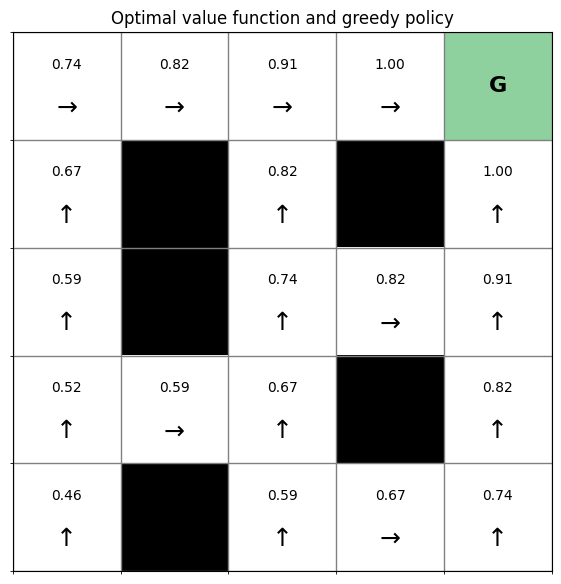

In [5]:
display_grid = np.zeros_like(grid, dtype=float)
display_grid[grid == -1] = -1
display_grid[goal_state] = 1

cmap = ListedColormap(["black", "white", "#8fd19e"])

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(display_grid + 1, cmap=cmap, vmin=0, vmax=2)

for row in range(n_rows):
    for col in range(n_cols):
        state = (row, col)

        if grid[state] == -1:
            continue

        if state == goal_state:
            ax.text(col, row, "G", ha="center", va="center", fontsize=16, weight="bold")
            continue

        ax.text(col, row - 0.2, f"{V[state]:.2f}", ha="center", va="center", fontsize=10)

        action = policy[state]
        arrow = {
            "up": "↑",
            "down": "↓",
            "left": "←",
            "right": "→"
        }[action]

        ax.text(col, row + 0.2, arrow, ha="center", va="center", fontsize=18)

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="gray", linewidth=1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Optimal value function and greedy policy")
plt.show()

Finally, we can roll out the policy from a chosen starting state. This shows how the optimal policy behaves as an actual trajectory through the environment.

In [6]:
def rollout(start_state, policy, max_steps=30):
    state = start_state
    path = [state]
    rewards = []

    for t in range(max_steps):
        action = policy[state]

        if action in ["goal", "wall"]:
            break

        next_state, reward, done = step(state, action)
        path.append(next_state)
        rewards.append(reward)
        state = next_state

        if done:
            break

    return path, rewards

start_state = (4, 0)
path, rewards = rollout(start_state, policy)

print("Path:", path)
print("Return:", sum(gamma**t * r for t, r in enumerate(rewards)))

Path: [(4, 0), (3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4)]
Return: 0.45700713296874973


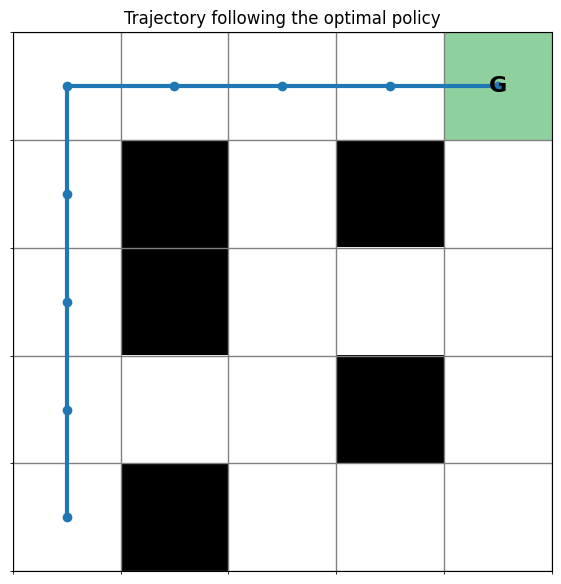

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(display_grid + 1, cmap=cmap, vmin=0, vmax=2)

for row in range(n_rows):
    for col in range(n_cols):
        if grid[row, col] == -1:
            continue
        if (row, col) == goal_state:
            ax.text(col, row, "G", ha="center", va="center", fontsize=16, weight="bold")

path_rows = [state[0] for state in path]
path_cols = [state[1] for state in path]

ax.plot(path_cols, path_rows, marker="o", linewidth=3, color="tab:blue")

ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="gray", linewidth=1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Trajectory following the optimal policy")
plt.show()

This example shows the basic dynamic programming idea. If the transition model is known, we can repeatedly apply the Bellman optimality update until the value function becomes consistent with optimal behavior.

The value function tells us how promising each state is. The policy tells us what action to take. In dynamic programming, these two objects are tightly connected: once we know the optimal value function, we can obtain an optimal policy by acting greedily with respect to it.

### Frozen lake with Dynamic Programming example using Gym

The following is an example of dynamic programming for the frozen lake example, taken from Xiao ch. 3

In [13]:
import sys
import logging
import itertools

import numpy as np
np.random.seed(0)
import gymnasium as gym

logging.basicConfig(level=logging.INFO,
        format='%(asctime)s [%(levelname)s] %(message)s',
        stream=sys.stdout, datefmt='%H:%M:%S')

env = gym.make('FrozenLake-v1')
for key in vars(env.spec):
    logging.info('%s: %s', key, vars(env.spec)[key])
for key in vars(env.unwrapped):
    logging.info('%s: %s', key, vars(env.unwrapped)[key])

11:30:01 [INFO] id: FrozenLake-v1
11:30:01 [INFO] entry_point: gymnasium.envs.toy_text.frozen_lake:FrozenLakeEnv
11:30:01 [INFO] reward_threshold: 0.7
11:30:01 [INFO] nondeterministic: False
11:30:01 [INFO] max_episode_steps: 100
11:30:01 [INFO] order_enforce: True
11:30:01 [INFO] disable_env_checker: False
11:30:01 [INFO] kwargs: {'map_name': '4x4'}
11:30:01 [INFO] additional_wrappers: ()
11:30:01 [INFO] vector_entry_point: None
11:30:01 [INFO] namespace: None
11:30:01 [INFO] name: FrozenLake
11:30:01 [INFO] version: 1
11:30:01 [INFO] desc: [[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]
11:30:01 [INFO] nrow: 4
11:30:01 [INFO] ncol: 4
11:30:01 [INFO] reward_range: (0, 1)
11:30:01 [INFO] initial_state_distrib: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
11:30:01 [INFO] P: {0: {0: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)], 1: [(0.33333333333333337, 0, 0, False), (0.333333

In [15]:
class ClosedFormAgent:
    def __init__(self, env):
        state_n, action_n = env.observation_space.n, env.action_space.n
        v = np.zeros((env.spec.max_episode_steps+1, state_n))
        q = np.zeros((env.spec.max_episode_steps+1, state_n, action_n))
        pi = np.zeros((env.spec.max_episode_steps+1, state_n))
        P = env.unwrapped.P

        for t in range(env.spec.max_episode_steps-1, -1, -1):
            for s in range(state_n):
                for a in range(action_n):
                    for p, next_s, r, d in P[s][a]:
                        q[t, s, a] += p * (r + (1. - float(d)) * v[t+1, next_s])
                v[t, s] = q[t, s].max()
                pi[t, s] = q[t, s].argmax()
        self.pi = pi

    def reset(self, mode=None):
        self.t = 0

    def step(self, observation, reward, terminated):
        action = self.pi[self.t, observation]
        self.t += 1
        return action

    def close(self):
        pass


agent = ClosedFormAgent(env)

In [16]:
def play_episode(env, agent, seed=None, mode=None, render=False):
    observation, _ = env.reset(seed=seed)
    reward, terminated, truncated = 0., False, False
    agent.reset(mode=mode)
    episode_reward, elapsed_steps = 0., 0
    while True:
        action = agent.step(observation, reward, terminated)
        if render:
            env.render()
        if terminated or truncated:
            break
        observation, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        elapsed_steps += 1
    agent.close()
    return episode_reward, elapsed_steps


logging.info('==== test ====')
episode_rewards = []
for episode in range(100):
    episode_reward, elapsed_steps = play_episode(env, agent)
    episode_rewards.append(episode_reward)
    logging.info('test episode %d: reward = %.2f, steps = %d',
            episode, episode_reward, elapsed_steps)
logging.info('average episode reward = %.2f ± %.2f',
        np.mean(episode_rewards), np.std(episode_rewards))

env.close()

11:31:35 [INFO] ==== test ====
11:31:35 [INFO] test episode 0: reward = 1.00, steps = 51
11:31:35 [INFO] test episode 1: reward = 0.00, steps = 79
11:31:35 [INFO] test episode 2: reward = 0.00, steps = 48
11:31:35 [INFO] test episode 3: reward = 0.00, steps = 29
11:31:35 [INFO] test episode 4: reward = 1.00, steps = 41
11:31:35 [INFO] test episode 5: reward = 1.00, steps = 74
11:31:35 [INFO] test episode 6: reward = 1.00, steps = 21
11:31:35 [INFO] test episode 7: reward = 1.00, steps = 100
11:31:35 [INFO] test episode 8: reward = 0.00, steps = 24
11:31:35 [INFO] test episode 9: reward = 1.00, steps = 50
11:31:35 [INFO] test episode 10: reward = 1.00, steps = 17
11:31:35 [INFO] test episode 11: reward = 1.00, steps = 30
11:31:35 [INFO] test episode 12: reward = 1.00, steps = 27
11:31:35 [INFO] test episode 13: reward = 1.00, steps = 56
11:31:35 [INFO] test episode 14: reward = 1.00, steps = 23
11:31:35 [INFO] test episode 15: reward = 1.00, steps = 26
11:31:35 [INFO] test episode 16: r

This example shows how dynamic programming can compute an optimal policy when the environment model is known. By working backward from the end of the episode, the agent estimates which states are valuable and which actions lead to the best future outcomes.

The important point is that the policy is obtained from the value function. Once the action values have been computed, the agent can act greedily by choosing the action with the highest value in each state.

## From the MDP framework to Monte Carlo learning

The agent--environment interaction is described by the state space $S$, action space $A$, reward space $R$, admissible actions $A(s)$, and transition-reward probability kernel

$$
p(s',r\mid s,a)
=
P(S_{t+1}=s',R_{t+1}=r\mid S_t=s,A_t=a).
$$

The set of admissible state-action pairs is

$$
D=\{(s,a):s\in S,\ a\in A(s)\}.
$$

The Markov property states that the current state-action pair contains all information from the past needed to describe the one-step distribution of the future. If

$$
H_t=(S_0,A_0,R_1,\ldots,S_t,A_t)
$$

is the history up to time $t$, then

$$
P(S_{t+1}=s',R_{t+1}=r\mid H_t)
=
p(s',r\mid S_t,A_t).
$$

A policy $\pi$ determines how the agent selects actions:

$$
\pi(a\mid s)=P(A_t=a\mid S_t=s).
$$

Together, the initial distribution $\mu_0$, policy $\pi$, and environment kernel $p$ determine the probability distribution over trajectories. A finite trajectory has the form

$$
\tau=(s_0,a_0,r_1,s_1,\ldots,a_{T-1},r_T,s_T),
$$

with probability

$$
P_\pi(\tau)
=
\mu_0(s_0)
\prod_{t=0}^{T-1}
\pi(a_t\mid s_t)
p(s_{t+1},r_{t+1}\mid s_t,a_t).
$$

The return from time $t$ is

$$
G_t
=
\sum_{k=0}^{T-t-1}
\gamma^kR_{t+k+1},
$$

and the value functions of a policy $\pi$ are

$$
v_\pi(s)
=
E_\pi[G_t\mid S_t=s]
$$

and

$$
q_\pi(s,a)
=
E_\pi[G_t\mid S_t=s,A_t=a].
$$

If the kernel $p(s',r\mid s,a)$ is known, these expectations can be evaluated through the Bellman equation:

$$
v_\pi(s)
=
\sum_{a\in A(s)}
\pi(a\mid s)
\sum_{s'\in S}
\sum_{r\in R}
p(s',r\mid s,a)
\left[r+\gamma v_\pi(s')\right].
$$

This gives a model-based approach: the known environment probabilities are used directly to update the value function.

## Monte Carlo learning

Monte Carlo learning is used when the kernel $p(s',r\mid s,a)$ is not known or is not used directly. Instead of summing over all possible next states and rewards, the agent follows a policy $\pi$ and generates complete episodes through interaction with the environment.

For each occurrence of a state $s$ at time $t$, the observed return

$$
G_t
=
R_{t+1}
+
\gamma R_{t+2}
+
\cdots
+
\gamma^{T-t-1}R_T
$$

provides one sample of the random return conditioned on $S_t=s$. If the observed returns following visits to $s$ are

$$
G^{(1)}(s),G^{(2)}(s),\ldots,G^{(N)}(s),
$$

then the Monte Carlo estimate of $v_\pi(s)$ is the sample average

$$
V_N(s)
=
\frac{1}{N}
\sum_{i=1}^{N}G^{(i)}(s).
$$

Similarly, returns observed after choosing action $a$ in state $s$ can be averaged to estimate $q_\pi(s,a)$:

$$
Q_N(s,a)
=
\frac{1}{N}
\sum_{i=1}^{N}G^{(i)}(s,a).
$$

The sample average can also be updated incrementally. After observing a new return $G^{(N+1)}(s)$,

$$
V_{N+1}(s)
=
V_N(s)
+
\frac{1}{N+1}
\left[
G^{(N+1)}(s)-V_N(s)
\right].
$$

In **first-visit Monte Carlo**, only the return following the first visit to a state in an episode is included. In **every-visit Monte Carlo**, the return following every visit is included.

Monte Carlo prediction estimates $v_\pi$ or $q_\pi$ for a fixed policy $\pi$. Monte Carlo control additionally uses the estimated action values to improve the policy. This requires sufficient exploration so that the relevant state-action pairs are visited repeatedly.

The essential transition from model-based evaluation to Monte Carlo learning is therefore a transition from exact expectations under the known kernel $p$ to sample averages computed from trajectories. Monte Carlo methods do not require the environment model, but they normally wait until an episode is complete before the returns can be calculated.

### $\varepsilon$-greedy exploration

When action values $Q(s,a)$ are estimated from experience, the agent must balance **exploitation** and **exploration**. Exploitation means choosing the action with the largest current estimate, while exploration means occasionally trying other actions to collect new information.

An $\varepsilon$-greedy policy chooses a greedy action with high probability and a random admissible action with probability $\varepsilon$. For a finite action set $A(s)$,

$$
\pi(a\mid s)
=
\begin{cases}
1-\varepsilon+\dfrac{\varepsilon}{|A(s)|},
& a\in\arg\max_{b\in A(s)}Q(s,b),\\[6pt]
\dfrac{\varepsilon}{|A(s)|},
& \text{otherwise}.
\end{cases}
$$

The parameter $\varepsilon\in[0,1]$ controls the amount of exploration. A small $\varepsilon$ favors the currently best-known actions, while a larger $\varepsilon$ produces more exploration.

The main purpose of $\varepsilon$-greedy exploration is to prevent the agent from committing too early to inaccurate value estimates. By continuing to sample different actions, the agent can improve its estimates of $q_\pi(s,a)$ and discover actions that initially appeared less valuable.